In [1]:
import pandas as pd

In [2]:
df=pd.read_excel(r"D:\Project4\chatgpt_style_reviews_dataset (1).xlsx")
df

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No
...,...,...,...,...,...,...,...,...,...,...,...,...
495,2024-07-05 00:00:00,Review title 496,"Waste of time, does not meet expectations.",2,user496,81,7,Flipkart,ja,Qatar,1.2.3,No
496,########,Review title 497,"Great experience, smooth performance and usefu...",5,user497,48,7,Google Play,fr,Nepal,2.1.4,No
497,########,Review title 498,"Terrible experience, needs major improvements.",2,user498,16,5,Google Play,de,Poland,2.1.4,Yes
498,########,Review title 499,"Highly satisfied, the app works exactly as exp...",4,user499,68,8,Google Play,zh,Nepal,1.2.3,Yes


In [3]:
df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase'],
      dtype='object')

In [4]:
df.dtypes

date                 object
title                object
review               object
rating                int64
username             object
helpful_votes         int64
review_length         int64
platform             object
language             object
location             object
version              object
verified_purchase    object
dtype: object

In [5]:
df.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
dtype: int64

In [6]:
df['date'] = df['date'].replace("########", pd.NA)

In [7]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

In [8]:
df = df.dropna(subset=['date'])

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ashwi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ashwi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)
df.head()

C:\Users\ashwi\AppData\Local\Temp\ipykernel_9608\2393723259.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_review'] = df['review'].apply(clean_text)


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,clean_review
5,2024-05-05,Review title 6,"Waste of time, does not meet expectations.",2,user6,156,7,App Store,en,Nepal,3.5.6,No,waste time meet expectation
6,2024-03-09,Review title 7,"Highly satisfied, the app works exactly as exp...",4,user7,186,8,Google Play,fr,Qatar,2.1.4,No,highly satisfied app work exactly expected
7,2024-03-08,Review title 8,"Highly satisfied, the app works exactly as exp...",4,user8,152,8,Amazon,ja,Italy,5.0.3,No,highly satisfied app work exactly expected
14,2024-06-02,Review title 15,Works fine but there is room for improvement.,3,user15,78,8,Flipkart,hi,USA,3.5.6,Yes,work fine room improvement
18,2024-06-05,Review title 19,"Excellent app, very easy to use and extremely ...",5,user19,33,9,Website,pt,USA,5.0.3,No,excellent app easy use extremely helpful


In [11]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(rating_to_sentiment)
df["sentiment"].value_counts()


C:\Users\ashwi\AppData\Local\Temp\ipykernel_9608\34244997.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentiment"] = df["rating"].apply(rating_to_sentiment)


Negative    58
Positive    54
Neutral     30
Name: sentiment, dtype: int64

In [12]:
df

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,clean_review,sentiment
5,2024-05-05,Review title 6,"Waste of time, does not meet expectations.",2,user6,156,7,App Store,en,Nepal,3.5.6,No,waste time meet expectation,Negative
6,2024-03-09,Review title 7,"Highly satisfied, the app works exactly as exp...",4,user7,186,8,Google Play,fr,Qatar,2.1.4,No,highly satisfied app work exactly expected,Positive
7,2024-03-08,Review title 8,"Highly satisfied, the app works exactly as exp...",4,user8,152,8,Amazon,ja,Italy,5.0.3,No,highly satisfied app work exactly expected,Positive
14,2024-06-02,Review title 15,Works fine but there is room for improvement.,3,user15,78,8,Flipkart,hi,USA,3.5.6,Yes,work fine room improvement,Neutral
18,2024-06-05,Review title 19,"Excellent app, very easy to use and extremely ...",5,user19,33,9,Website,pt,USA,5.0.3,No,excellent app easy use extremely helpful,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,2025-03-06,Review title 482,"Waste of time, does not meet expectations.",1,user482,144,7,Flipkart,en,Germany,4.2.1,Yes,waste time meet expectation,Negative
488,2024-01-04,Review title 489,"Highly satisfied, the app works exactly as exp...",4,user489,123,8,Website,zh,Italy,4.2.1,No,highly satisfied app work exactly expected,Positive
490,2024-04-04,Review title 491,"Terrible experience, needs major improvements.",1,user491,12,5,Flipkart,en,Qatar,4.2.1,Yes,terrible experience need major improvement,Negative
495,2024-07-05,Review title 496,"Waste of time, does not meet expectations.",2,user496,81,7,Flipkart,ja,Qatar,1.2.3,No,waste time meet expectation,Negative


In [13]:
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_review"],
    df["sentiment"],
    test_size=0.3,
    random_state=42,
    stratify=df["sentiment"]
)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2) # bigrams for stronger pattern memorization
)

In [15]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        18
     Neutral       1.00      1.00      1.00         9
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43



In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("\nCross Validation Accuracy:", cv_scores.mean())


Cross Validation Accuracy: 1.0


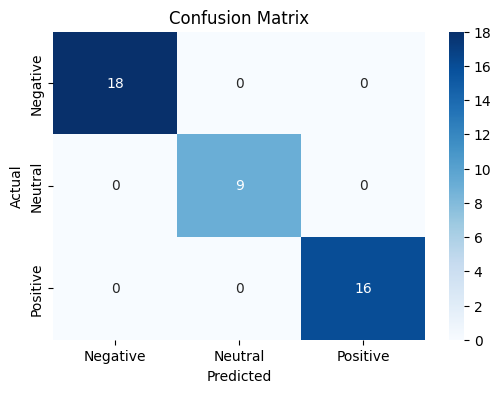

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [21]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("\nCross Validation Accuracy:", cv_scores.mean())


Cross Validation Accuracy: 1.0


In [22]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        18
     Neutral       1.00      1.00      1.00         9
    Positive       1.00      1.00      1.00        16

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43



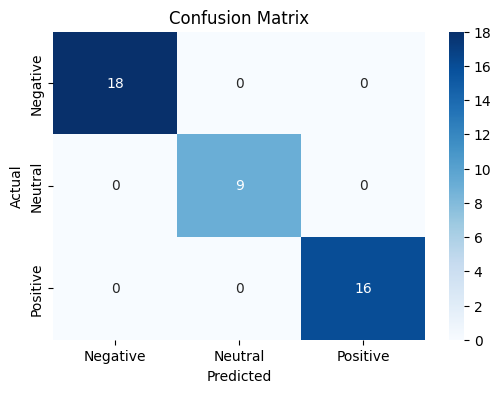

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [24]:
df['review'].value_counts()

Poor performance and not user-friendly.                      20
Waste of time, does not meet expectations.                   14
Excellent app, very easy to use and extremely helpful.       14
Great experience, smooth performance and useful features.    14
Very disappointing experience, the app crashes often.        12
Very reliable and worth using regularly.                     10
Highly satisfied, the app works exactly as expected.          9
The app is okay and does its job reasonably well.             8
Decent app, neither too good nor too bad.                     7
Amazing quality and user-friendly interface.                  7
Terrible experience, needs major improvements.                7
Average experience, some features could be improved.          6
Works fine but there is room for improvement.                 5
Not satisfied, many bugs and issues.                          5
Not bad, but updates are needed for better performance.       4
Name: review, dtype: int64

In [ ]:
import pickle

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("stopwords.pkl", "wb") as f:
    pickle.dump(stop_words, f)

with open("lemmatizer.pkl", "wb") as f:
    pickle.dump(lemmatizer, f)


In [ ]:
with open("dashboard_data.pkl", "wb") as f:
    pickle.dump(df, f)


## 1. What is the distribution of review ratings?

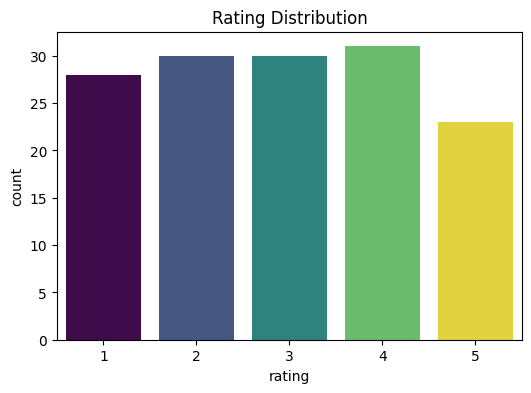

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='rating', hue='rating', data=df, palette='viridis', legend=False)
plt.title("Rating Distribution")
plt.show()

# 2. How many reviews were marked as helpful (above a certain threshold)?

In [26]:
df['helpful_category'] = df['helpful_votes'].apply(
    lambda x: 'Helpful' if x > 10 else 'Not Helpful'
)

df['helpful_category'].value_counts()


C:\Users\ashwi\AppData\Local\Temp\ipykernel_9608\2637210600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['helpful_category'] = df['helpful_votes'].apply(


Helpful        140
Not Helpful      2
Name: helpful_category, dtype: int64

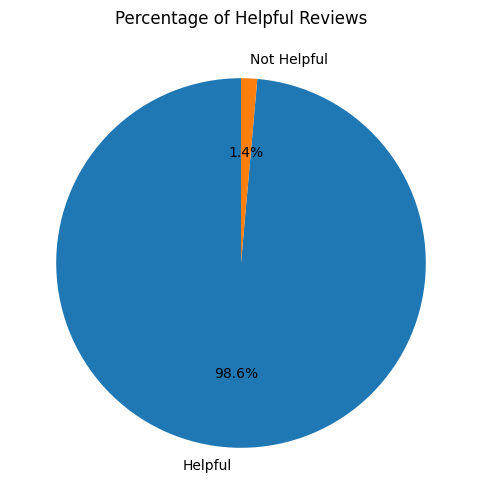

In [27]:
helpful_counts = df['helpful_category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(helpful_counts, labels=helpful_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Percentage of Helpful Reviews")
plt.show()


# 3. What are the most common keywords in positive vs. negative reviews?

In [28]:
positive_reviews = df[df['rating'] >= 4]['clean_review']
negative_reviews = df[df['rating'] <= 2]['clean_review']

positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)


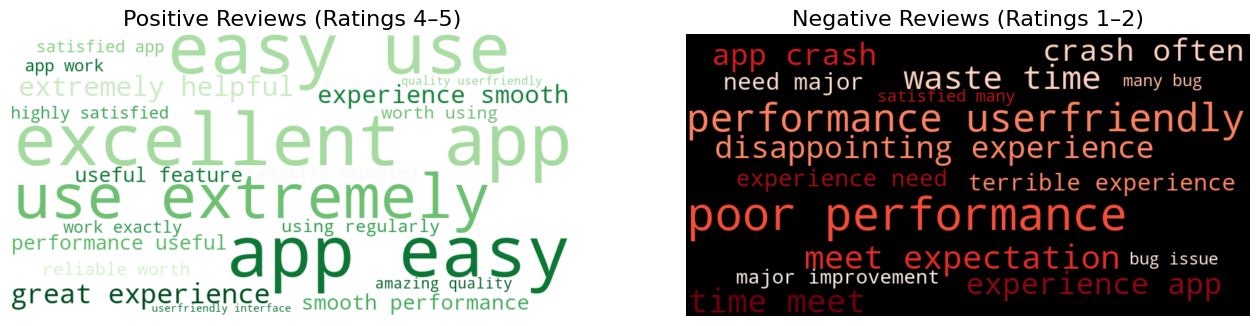

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Positive WordCloud
wc_pos = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens"
).generate(positive_text)

# Negative WordCloud
wc_neg = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="Reds"
).generate(negative_text)

# Plot both side by side
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews (Ratings 4–5)", fontsize=16)

plt.subplot(1,2,2)
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews (Ratings 1–2)", fontsize=16)

plt.show()


# 4. How has the average rating changed over time?


In [31]:
df['year_month'] = df['date'].dt.to_period('M')

C:\Users\ashwi\AppData\Local\Temp\ipykernel_9608\4047067555.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['date'].dt.to_period('M')


In [32]:
monthly_avg = df.groupby('year_month')['rating'].mean().reset_index()
monthly_avg['year_month'] = monthly_avg['year_month'].dt.to_timestamp()

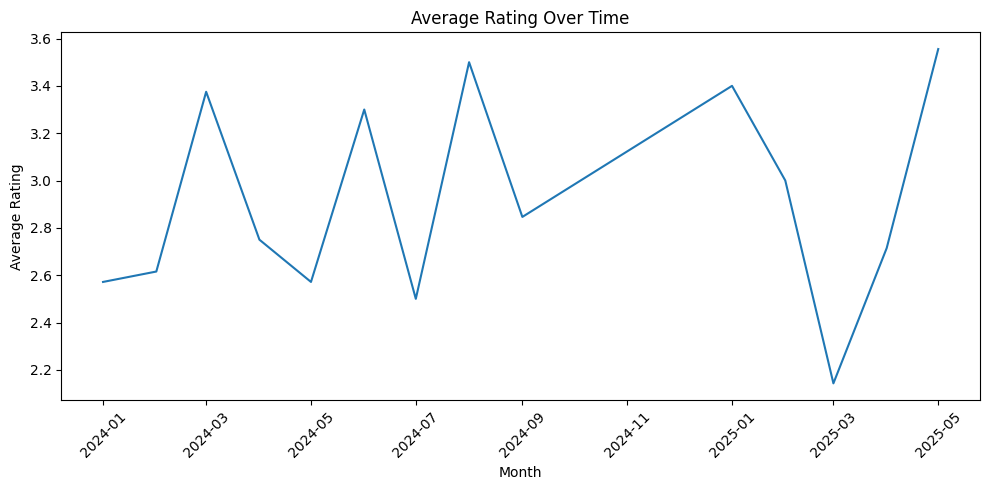

In [33]:
plt.figure(figsize=(10,5))
plt.plot(monthly_avg['year_month'], monthly_avg['rating'])
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.title("Average Rating Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. How do ratings vary by user location?


In [34]:
df['location'].value_counts()

Germany    19
Qatar      17
USA        16
India      16
Italy      15
Poland     13
Kenya      13
UK         12
France     12
Nepal       9
Name: location, dtype: int64

In [35]:
location_ratings = df.groupby('location')['rating'].mean().sort_values(ascending=False)
location_ratings


location
UK         3.583333
Nepal      3.555556
Italy      3.133333
Poland     3.076923
India      3.000000
USA        3.000000
Kenya      2.923077
Germany    2.789474
France     2.666667
Qatar      2.117647
Name: rating, dtype: float64

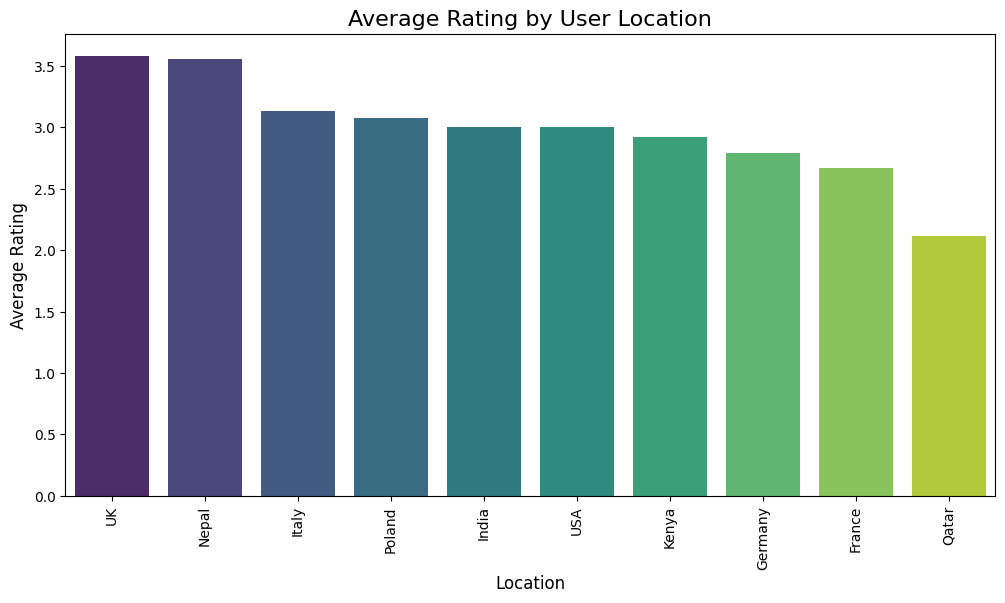

In [36]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=location_ratings.index,
    y=location_ratings.values,
    hue=location_ratings.index,
    palette="viridis",
    legend=False
)


plt.xticks(rotation=90)
plt.title("Average Rating by User Location", fontsize=16)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.show()


# 6. Which platform gets better reviews?


In [37]:
platform_ratings = df.groupby('platform')['rating'].mean().sort_values(ascending=False)
print(platform_ratings)


platform
Website        3.281250
Google Play    3.050000
Amazon         2.862069
App Store      2.846154
Flipkart       2.685714
Name: rating, dtype: float64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_9608\3828146562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


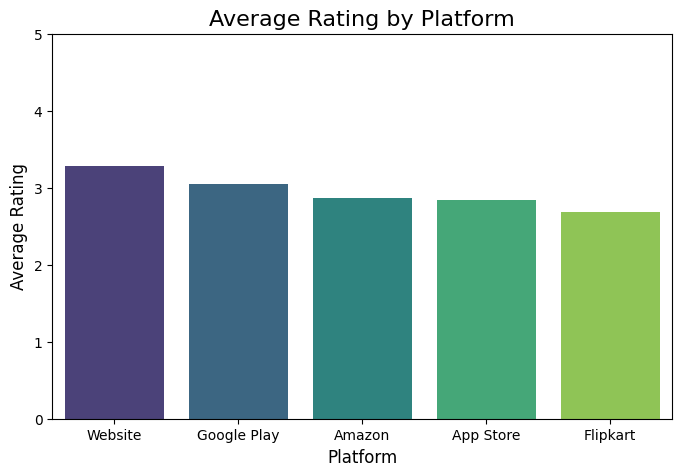

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    x=platform_ratings.index,
    y=platform_ratings.values,
    palette="viridis"
)

plt.title("Average Rating by Platform", fontsize=16)
plt.xlabel("Platform", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.ylim(0, 5)
plt.show()


# 7. Are verified users more satisfied than non-verified ones?


In [39]:
df['verified_purchase'].value_counts()


No     80
Yes    62
Name: verified_purchase, dtype: int64

In [40]:
verified_ratings = df.groupby('verified_purchase')['rating'].mean()
verified_ratings


verified_purchase
No     3.01250
Yes    2.83871
Name: rating, dtype: float64

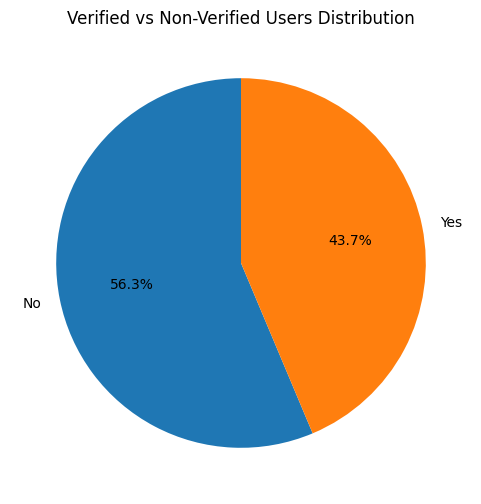

In [41]:
plt.figure(figsize=(6,6))
plt.pie(
    df['verified_purchase'].value_counts(),
    labels=df['verified_purchase'].value_counts().index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Verified vs Non-Verified Users Distribution")
plt.show()


# 8. What’s the average length of reviews per rating category?


In [42]:
df['review_length'] = df['review'].apply(lambda x: len(str(x)))


C:\Users\ashwi\AppData\Local\Temp\ipykernel_9608\4172425247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_length'] = df['review'].apply(lambda x: len(str(x)))


In [43]:
avg_length_by_rating = df.groupby('rating')['review_length'].mean()
avg_length_by_rating


rating
1    42.678571
2    43.700000
3    47.866667
4    50.516129
5    50.608696
Name: review_length, dtype: float64

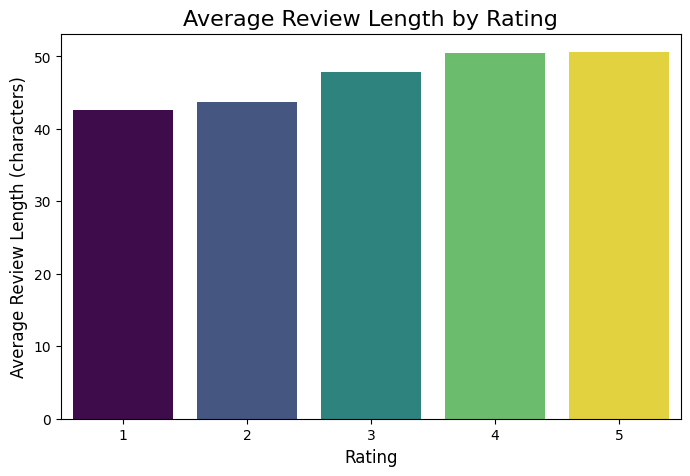

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_length_by_rating.index,
    y=avg_length_by_rating.values,
    hue=avg_length_by_rating.index,
    palette="viridis",
    legend=False
)

plt.title("Average Review Length by Rating", fontsize=16)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Average Review Length (characters)", fontsize=12)
plt.show()


# 9. What are the most mentioned words in 1-star reviews?


In [45]:
one_star_reviews = df[df['rating'] == 1]['clean_review']


In [46]:
one_star_text = " ".join(one_star_reviews)


In [47]:
pip install --upgrade wordcloud


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


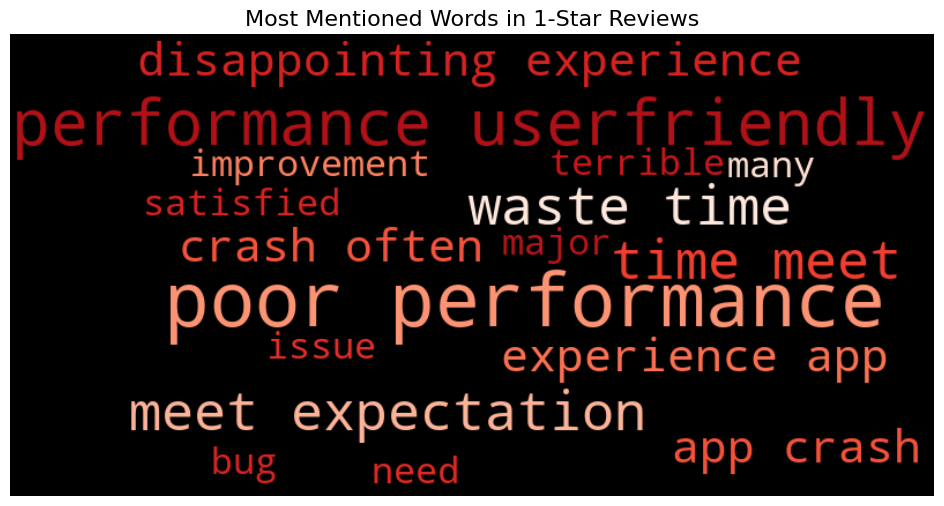

In [48]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc_1star = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Reds'
).generate(one_star_text)

plt.figure(figsize=(12,6))
plt.imshow(wc_1star.to_array(), interpolation='bilinear')
plt.axis('off')
plt.title("Most Mentioned Words in 1-Star Reviews", fontsize=16)
plt.show()


# 10. What ChatGPT version received the highest average rating?


In [49]:
df['version'].value_counts()


2.1.4    29
4.2.1    29
1.2.3    29
3.5.6    28
5.0.3    27
Name: version, dtype: int64

In [50]:
version_avg = df.groupby('version')['rating'].mean().sort_values(ascending=False)
version_avg


version
1.2.3    3.103448
2.1.4    3.000000
5.0.3    2.925926
4.2.1    2.827586
3.5.6    2.821429
Name: rating, dtype: float64

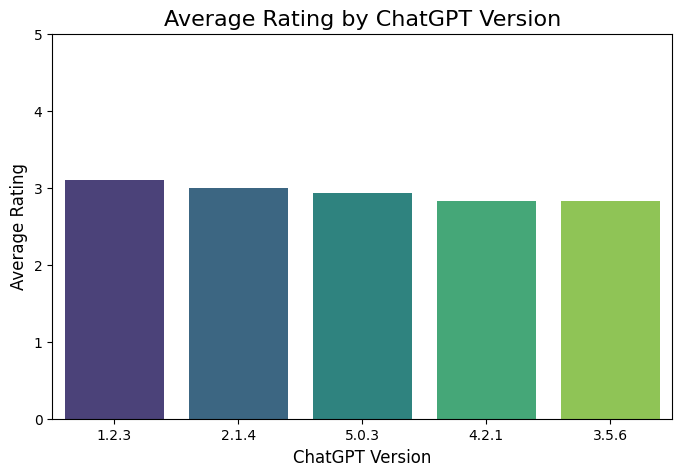

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=version_avg.index,
    y=version_avg.values,
    hue=version_avg.index,
    palette="viridis",
    legend=False
)

plt.title("Average Rating by ChatGPT Version", fontsize=16)
plt.xlabel("ChatGPT Version", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.ylim(0,5)
plt.show()
